In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

Reproducibility

In [2]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

In [4]:
plt.rcParams.update({
    "font.size":        16,
    "axes.titlesize":   18,
    "axes.labelsize":   17,
    "xtick.labelsize":  15,
    "ytick.labelsize":  15,
    "legend.fontsize":  15,
})

Hyperparameters

In [5]:
phi      = 6.0
n_values = [0.01, 0.5]
colors   = ["tab:green", "tab:orange"]
EPOCHS   = 15000
N_TRAIN  = 3000
BIAS_POW = 5.0

def phi_star(n):
    return np.sqrt(2.0 * (n + 1.0)) / (1.0 - n)

Model

In [6]:
class FreeBoundaryPINN(nn.Module):
    def __init__(self, p, width=64, depth=4):
        super().__init__()
        self.p = p
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

        self.xdz_param = nn.Parameter(torch.tensor([0.0], dtype=torch.float64))
        self.eps = 1e-4

    @property
    def xdz(self):
        return torch.sigmoid(self.xdz_param) * (1.0 - self.eps)

    def forward(self, xi):
        M = self.net(xi)
        B = 1.0 + (1.0 - xi) * M
        return (xi ** self.p) * (B ** 2)

Physics loss

In [7]:
def physics_loss(model, xi, phi, n):
    xi  = xi.clone().detach().requires_grad_(True)
    L   = 1.0 - model.xdz
    u   = model(xi)
    dudxi   = torch.autograd.grad(u,     xi, torch.ones_like(u),     create_graph=True)[0]
    d2udxi2 = torch.autograd.grad(dudxi, xi, torch.ones_like(dudxi), create_graph=True)[0]
    u_xx = d2udxi2 / (L ** 2)
    return torch.mean((u_xx - phi**2 * u**n) ** 2)

Sampling

In [8]:
def sample_xi(N, bias_power=5.0):
    Nu = N // 2; Nb = N - Nu
    return torch.cat([torch.rand(Nu, 1, device=device),
                      torch.rand(Nb, 1, device=device) ** bias_power], dim=0)

Reference solutions

In [9]:
def analytical_free_boundary(x, phi, n):
    ps = phi_star(n)
    if phi <= ps:
        return None, 0.0
    xdz = 1.0 - ps / phi
    p   = 2.0 / (1.0 - n)
    u   = np.zeros_like(x)
    mask = x > xdz
    u[mask] = ((x[mask] - xdz) / (1.0 - xdz)) ** p
    return u, xdz

def numeric_full_domain(x, phi, n):
    def solve_for_a(a):
        def rhs(t, y): return [y[1], phi**2 * max(y[0], 0.0)**n]
        return solve_ivp(rhs, [0,1], [a,0], t_eval=[1.0], rtol=1e-9, atol=1e-9).y[0,-1] - 1.0
    a_lo, a_hi = 1e-8, 5.0
    while solve_for_a(a_lo) * solve_for_a(a_hi) > 0:
        a_hi *= 2.0
        if a_hi > 1e6: raise RuntimeError("Bracket failed")
    a_star = root_scalar(solve_for_a, bracket=[a_lo, a_hi], method="brentq", xtol=1e-12).root
    def rhs(t, y): return [y[1], phi**2 * max(y[0], 0.0)**n]
    return solve_ivp(rhs, [0,1], [a_star,0], t_eval=x, rtol=1e-9, atol=1e-9).y[0], 0.0


Train

In [10]:
def train_model(n, phi, epochs=EPOCHS, N_train=N_TRAIN, bias_power=BIAS_POW):
    p = 2.0 / (1.0 - n)
    print(f"\n{'='*55}")
    print(f"  Training  n={n}  phi={phi}  p={p:.4f}  phi*={phi_star(n):.4f}")
    print(f"  epochs={epochs}  N_train={N_train}  bias_power={bias_power}")
    print('='*55)

    model = FreeBoundaryPINN(p=p).to(device)

    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=500, factor=0.5)

    for epoch in range(epochs + 1):
        xi   = sample_xi(N_train, bias_power)
        opt.zero_grad()
        loss = physics_loss(model, xi, phi, n)
        loss.backward()
        opt.step()
        sched.step(loss)
        if epoch % 500 == 0:
            print(f"  epoch {epoch:5d} | loss {loss.item():.3e} | x_dz {model.xdz.item():.6f}")

    # LBFGS refinement — two passes
    for n_pts in [4000, 8000]:
        lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=500,
                                    line_search_fn="strong_wolfe")
        last_loss = [None]
        def closure():
            lbfgs.zero_grad()
            l = physics_loss(model, sample_xi(n_pts, bias_power + 1), phi, n)
            l.backward()
            last_loss[0] = l.item()
            return l
        lbfgs.step(closure)
        print(f"  LBFGS ({n_pts:5d} pts) | loss {last_loss[0]:.3e} | x_dz {model.xdz.item():.6f}")

    return model

Evaluate

In [11]:
def evaluate_model(model, n, phi):
    model.eval()
    xdz_l = model.xdz.item()

    x_dead  = np.linspace(0.0, xdz_l, 200)
    xi_eval = torch.linspace(0, 1, 600, device=device).view(-1, 1)
    with torch.no_grad():
        u_live = model(xi_eval).cpu().numpy().reshape(-1)
    x_live = xdz_l + (1.0 - xdz_l) * xi_eval.cpu().numpy().reshape(-1)

    x_pinn = np.concatenate([x_dead, x_live])
    u_pinn = np.concatenate([np.zeros_like(x_dead), u_live])

    x_ref = np.linspace(0.0, 1.0, 1200)
    u_ref, xdz_ref = analytical_free_boundary(x_ref, phi, n)
    if u_ref is None:
        u_ref, xdz_ref = numeric_full_domain(x_ref, phi, n)

    u_interp = np.interp(x_ref, x_pinn, u_pinn)
    abs_err  = np.abs(u_interp - u_ref)
    L2       = np.sqrt(trapezoid(abs_err**2, x_ref))
    print(f"  n={n} | learned x_dz={xdz_l:.6f} | ref x_dz={xdz_ref:.6f} | L2={L2:.3e}")

    return dict(x_pinn=x_pinn, u_pinn=u_pinn,
                x_ref=x_ref,   u_ref=u_ref,
                xdz_l=xdz_l,  xdz_ref=xdz_ref,
                abs_err=abs_err)

Run our n values

In [12]:
results = {}
for n in n_values:
    model      = train_model(n, phi)
    results[n] = evaluate_model(model, n, phi)


  Training  n=0.01  phi=6.0  p=2.0202  phi*=1.4356
  epochs=15000  N_train=3000  bias_power=5.0


c:\ProgramData\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:1343: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  current = float(metrics)


  epoch     0 | loss 7.225e+02 | x_dz 0.500200
  epoch   500 | loss 2.865e+02 | x_dz 0.633908
  epoch  1000 | loss 1.133e+01 | x_dz 0.745664
  epoch  1500 | loss 5.177e-01 | x_dz 0.760638
  epoch  2000 | loss 1.775e-02 | x_dz 0.760724
  epoch  2500 | loss 3.584e-04 | x_dz 0.760723
  epoch  3000 | loss 3.094e-04 | x_dz 0.760727
  epoch  3500 | loss 8.458e-04 | x_dz 0.760727
  epoch  4000 | loss 8.199e-02 | x_dz 0.760727
  epoch  4500 | loss 1.379e-01 | x_dz 0.760728
  epoch  5000 | loss 1.664e-04 | x_dz 0.760729
  epoch  5500 | loss 8.947e-05 | x_dz 0.760729
  epoch  6000 | loss 7.330e-04 | x_dz 0.760729
  epoch  6500 | loss 7.780e-02 | x_dz 0.760720
  epoch  7000 | loss 5.571e-05 | x_dz 0.760729
  epoch  7500 | loss 2.949e-05 | x_dz 0.760729
  epoch  8000 | loss 5.026e-02 | x_dz 0.760721
  epoch  8500 | loss 2.420e-05 | x_dz 0.760729
  epoch  9000 | loss 1.570e-05 | x_dz 0.760729
  epoch  9500 | loss 2.008e-05 | x_dz 0.760729
  epoch 10000 | loss 1.788e-05 | x_dz 0.760729
  epoch 10500

Plots

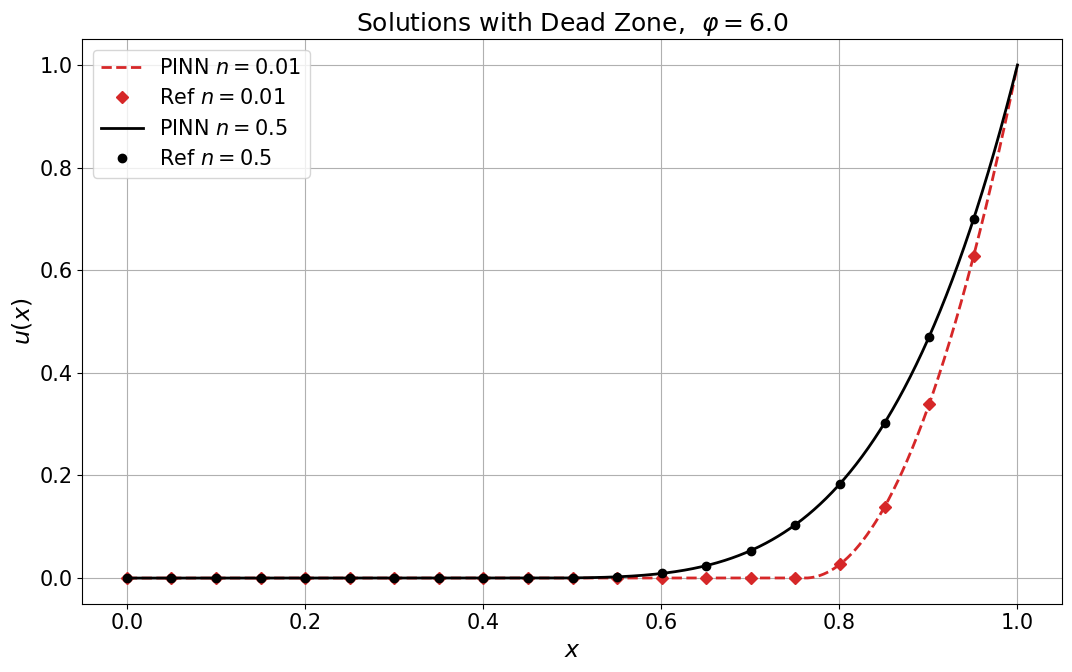

In [28]:
line_styles = {0.01: "--", 0.5: "-"}
dot_styles  = {0.01: "D", 0.5: "o"}
colors_bw = {0.01: "tab:red", 0.5: "black"}

fig, ax = plt.subplots(figsize=(11, 7))
for n in n_values:
    r  = results[n]
    ls = line_styles[n]
    mk = dot_styles[n]
    c  = colors_bw[n]

    ax.plot(r["x_pinn"], r["u_pinn"], lw=2, color=c, ls=ls,
            label=f"PINN $n={n}$")
    ax.plot(r["x_ref"], r["u_ref"], linestyle="none", marker=mk,
            color=c, markersize=6, markevery=60,
            label=f"Ref $n={n}$")

ax.set_xlabel("$x$"); ax.set_ylabel("$u(x)$")
ax.set_title(f"Solutions with Dead Zone,  $\\varphi = {phi}$")
ax.legend(); ax.grid(True); fig.tight_layout()
fig.savefig("figures/solution_dead_zone.pdf", format="pdf", bbox_inches="tight")
plt.show()

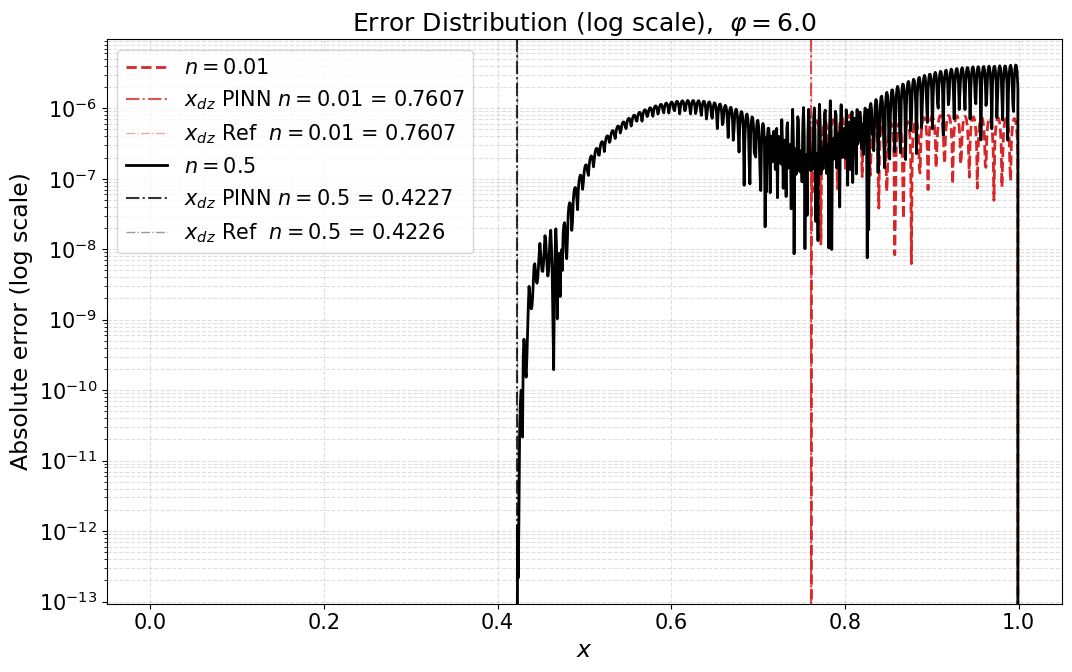

In [29]:
fig, ax = plt.subplots(figsize=(11, 7))
for n in n_values:
    r  = results[n]
    ls = line_styles[n]
    c  = colors_bw[n]

    ax.semilogy(r["x_ref"], r["abs_err"], lw=2, color=c, ls=ls,
                label=f"$n={n}$")
    ax.axvline(r["xdz_l"],   ls="-.", color=c, lw=1.5, alpha=0.8,
               label=f"$x_{{dz}}$ PINN $n={n}$ = {r['xdz_l']:.4f}")
    ax.axvline(r["xdz_ref"], ls="-.", color=c, lw=1.0, alpha=0.4,
               label=f"$x_{{dz}}$ Ref  $n={n}$ = {r['xdz_ref']:.4f}")

ax.set_xlabel("$x$"); ax.set_ylabel("Absolute error (log scale)")
ax.set_title(f"Error Distribution (log scale),  $\\varphi = {phi}$")
ax.legend(); ax.grid(True, which="both", ls="--", alpha=0.4)
fig.tight_layout()
fig.savefig("figures/error_overlay.pdf", format="pdf", bbox_inches="tight")
plt.show()

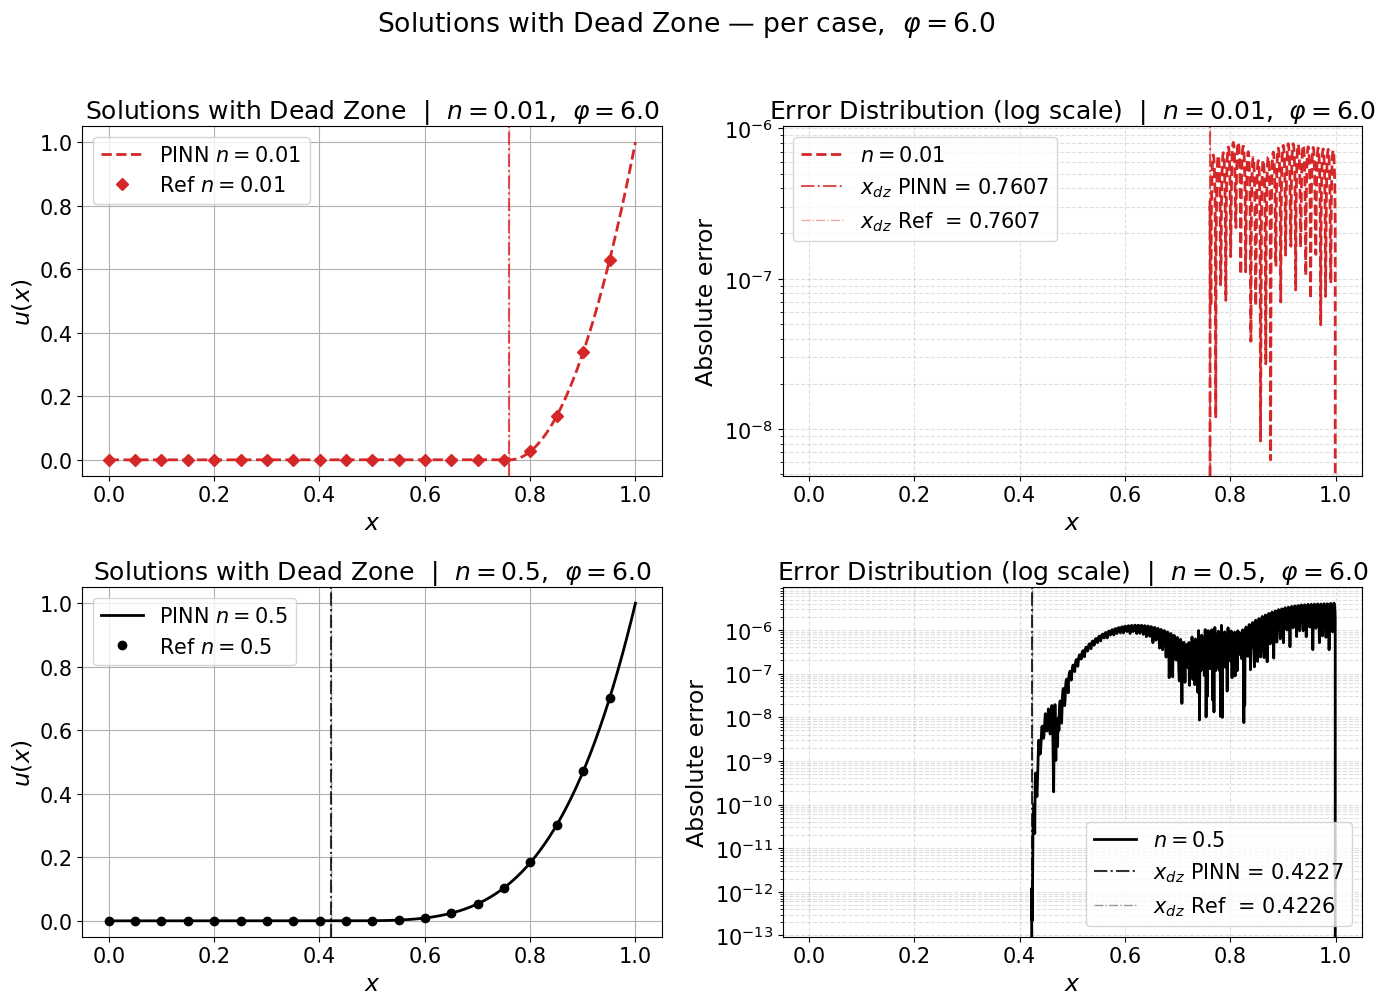

In [30]:
fig, axes = plt.subplots(len(n_values), 2, figsize=(14, 5 * len(n_values)))

for i, n in enumerate(n_values):
    r  = results[n]
    ls = line_styles[n]
    mk = dot_styles[n]
    c  = colors_bw[n]

    ax_sol = axes[i, 0]
    ax_sol.plot(r["x_pinn"], r["u_pinn"], lw=2, color=c, ls=ls,
                label=f"PINN $n={n}$")
    ax_sol.plot(r["x_ref"], r["u_ref"], linestyle="none", marker=mk,
                color=c, markersize=6, markevery=60,
                label=f"Ref $n={n}$")
    ax_sol.axvline(r["xdz_l"],   ls="-.", color=c, lw=1.5, alpha=0.8)
    ax_sol.axvline(r["xdz_ref"], ls="-.", color=c, lw=1.0, alpha=0.4)
    ax_sol.set_title(f"Solutions with Dead Zone  |  $n={n}$,  $\\varphi={phi}$")
    ax_sol.set_xlabel("$x$"); ax_sol.set_ylabel("$u(x)$")
    ax_sol.legend(); ax_sol.grid(True)

    ax_err = axes[i, 1]
    ax_err.semilogy(r["x_ref"], r["abs_err"], lw=2, color=c, ls=ls,
                    label=f"$n={n}$")
    ax_err.axvline(r["xdz_l"],   ls="-.", color=c, lw=1.5, alpha=0.8,
                   label=f"$x_{{dz}}$ PINN = {r['xdz_l']:.4f}")
    ax_err.axvline(r["xdz_ref"], ls="-.", color=c, lw=1.0, alpha=0.4,
                   label=f"$x_{{dz}}$ Ref  = {r['xdz_ref']:.4f}")
    ax_err.set_title(f"Error Distribution (log scale)  |  $n={n}$,  $\\varphi={phi}$")
    ax_err.set_xlabel("$x$"); ax_err.set_ylabel("Absolute error")
    ax_err.legend(); ax_err.grid(True, which="both", ls="--", alpha=0.4)

plt.suptitle(f"Solutions with Dead Zone — per case,  $\\varphi = {phi}$", y=1.01)
fig.tight_layout()
fig.savefig("figures/separate_plots.pdf", format="pdf", bbox_inches="tight")
plt.show()